Generating Extreme Event data for AMAS Project

from gaussian distribution

interested in the upper tail extremes

data is cut away 5 sigma from origin


original code by peter resch, 12.3.2026

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from matplotlib.markers import MarkerStyle
import os

my_cmap = plt.colormaps["turbo"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='6,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

save_figures = False

## #read in file

In [ ]:
print(os.getcwd())
#os.chdir("code/VWLS/")

/media/peter/OPENSTORAGE/PhysicsMSc/_Advanced Statistics/_Project/code/VWLS


In [40]:
"""dataset location"""
filename="gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv"
directory = "../data/generating_data_gauss"
filepath = directory+ "/" + filename
print(f"Filepath: {filepath}")

Filepath: ../data/generating_data_gauss/gauss-mu=5,sigma=2.0,N=e9,cutoff=4sig.csv


In [ ]:
"""read the values from the text file"""
extreme_values_from_file = []
with open(filepath, "r") as f:
    for line in f:
        extreme_values_from_file.append(float(line.strip()))

print(f"Number of extreme values: {len(extreme_values_from_file)}")

Number of extreme values: 33402


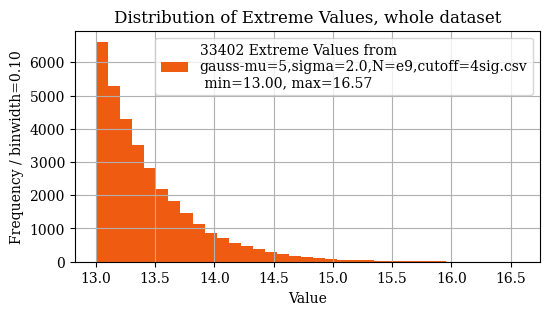

In [56]:
"""illustrating the distribution of the extreme values with a histogram"""
min_value = min(extreme_values_from_file)
max_value = max(extreme_values_from_file)
#n_bins = 50
bin_width = 0.1
n_bins = int((max_value - min_value) / bin_width)

plt.hist(extreme_values_from_file, bins=n_bins, alpha=1, color=my_cmap(0.8),label=f"{len(extreme_values_from_file)} Extreme Values from\n{filename}\n min={min_value:.2f}, max={max_value:.2f}")
plt.xlabel("Value")
plt.ylabel(f"Frequency / binwidth={bin_width:.2f}")
plt.title("Distribution of Extreme Values, whole dataset")
plt.grid()
plt.legend()
plt.show()

if save_figures:
    plt.savefig(f"{directory}/histogram_extreme_values_{filename}.png")

## #Selecting Distribution

In [54]:
"""define starting parameters for fitting the GEV distribution"""
shape_param = 0
mu_param = 0
sigma_param = 1

def gev_cdf(xi_array, shape_param, mu_param, sigma_param):
    return stats.genextreme.cdf(x=xi_array, c=shape_param, loc=mu_param, scale=sigma_param)

#stats.genextreme.cdf(c=shape_param, loc=mu_param, scale=sigma_param,x=xi)

# ##Selecting subset of data

In [55]:
"""select a subset of the extreme values for fitting the GEV distribution"""
subset_size = 1000
xi = extreme_values_from_file[:subset_size]

## #Weibull Plotting Positions

In [58]:
"""Ranking the data points"""
xi_ranked = np.sort(xi)


"""define Weibull plotting positions"""
def weibull_plotting_positions(xi_array,rank_m):
    n = len(xi_array)
    return rank_m / (n + 1)


print(f"Ranked data points: {xi_ranked[:10]}")

Ranked data points: [13.0000536  13.00025749 13.00029355 13.00073898 13.00172949 13.00221694
 13.00266184 13.0032182  13.00431465 13.00457321]


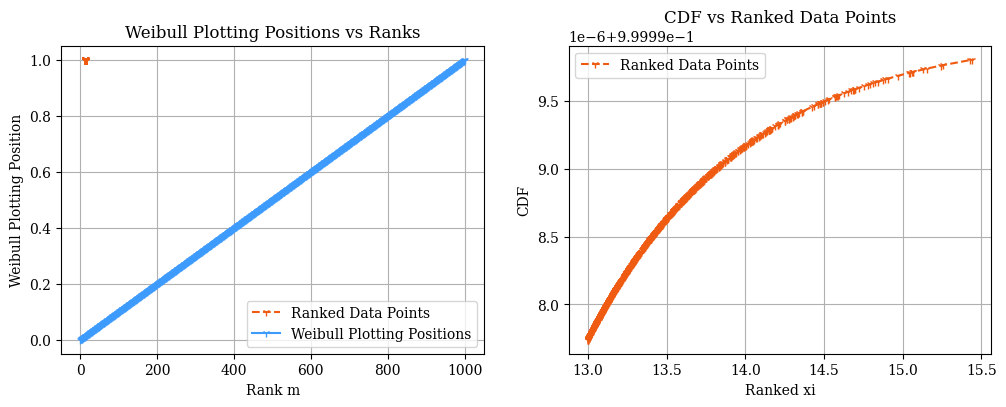

In [ ]:
"""Illustrating the ranked data points and their Weibull plotting positions"""
ranks_m = np.arange(1, subset_size + 1)
weibull_positions = weibull_plotting_positions(xi_ranked, ranks_m)
raise NotImplementedError("did not consider observable x correctly")
fig,[ax_weibull,ax_cdf]=plt.subplots(1,2,figsize=(12,4))
ax_weibull.plot(ranks_m, weibull_positions, color=my_cmap(0.2), label="Weibull Plotting Positions", marker=my_marker, linestyle='-')
ax_weibull.set_xlabel("Rank m")
ax_weibull.set_ylabel("Weibull Plotting Position")
ax_weibull.set_title("Weibull Plotting Positions vs Ranks")
ax_weibull.grid()
ax_weibull.legend()

ax_cdf.plot(xi_ranked,gev_cdf(xi_ranked,shape_param,mu_param,sigma_param), color=my_cmap(0.8), label="Ranked Data Points", marker=my_marker, linestyle='--')
ax_cdf.set_xlabel("Ranked xi")
ax_cdf.set_ylabel("CDF")
ax_cdf.set_title("CDF vs Ranked Data Points")
ax_cdf.grid()
ax_cdf.legend()

## #Weighing and fitting - functions

## #Reject data - function

## #Fitting process